# Styling and Plot Types

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

```{contents}
:local:
:depth: 2
```


```{index} styling charts
```
## Styling in Practice

This section turns a default chart into one a manager can read. Three levels decide how every chart looks, and each level overrides the one above it:

| Level | What it is | Applies to | Example |
|---|---|---|---|
| 1. `rcParams` | Matplotlib's built-in defaults for every part of a chart | Every chart drawn after you change it | `plt.rcParams['font.size'] = 13` |
| 2. Style sheet | A named bundle of `rcParams` values | Every chart drawn after you switch | `plt.style.use('ggplot')` |
| 3. Arguments | A setting passed in one plotting call | Only that element | `ax.plot(x, y, lw=2)` |

For example, lines are 1.5 points wide by default (`rcParams`). A style sheet can change that for every line, and `ax.plot(x, y, lw=2)` makes just that one line 2 points wide, whatever the other two levels say. Set the look of a whole report at the first two levels, then use arguments for the elements that need to stand out.

The first two sections cover the two report-wide levels; the rest of this section covers the arguments you use most: legends, axis ranges, colors, and line styles.

```{index} rcParams
```
### `rcParams`

Every part of a chart has a default setting: the font size, line width, colors, grid lines, figure size, and many more. Matplotlib keeps all of these defaults in `plt.rcParams` and looks one up whenever you don't choose a value yourself. The name comes from *runtime configuration* ("rc"): Matplotlib loads the defaults from a settings file called `matplotlibrc` when it starts, and you can change them while your program runs.

This is handy when a report has many charts. Set the font size and grid once in `rcParams` instead of repeating `fontsize=` in every call, and every chart matches.

Each setting has a name, and you can look up its current value:

In [3]:
print(plt.rcParams['font.size'])      ### the default font size, in points
print(plt.rcParams['axes.grid'])      ### are grid lines on by default?
print(len(plt.rcParams), 'settings in total')

10.0
False
339 settings in total


Setting `plt.rcParams['font.size'] = 13` changes every chart drawn afterward. To try settings on one chart only, use `plt.rc_context()`, as in the next cell; the rest of the notebook keeps its defaults.

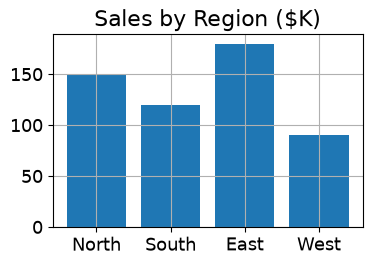

In [3]:
regions = ['North', 'South', 'East', 'West']
sales = [150, 120, 180, 90]

### plt.rcParams['font.size'] = 13 would change every later chart;
### plt.rc_context() changes it only inside this block
with plt.rc_context({'font.size': 13, 'axes.grid': True}):
    fig, ax = plt.subplots(figsize=(4, 2.5))
    ax.bar(regions, sales)
    ax.set_title('Sales by Region ($K)')
    plt.show()

```{index} style sheet (plt.style.use)
```
### Style Sheets

A **style sheet** is a named bundle of `rcParams` values (colors, fonts, grid lines, and so on) chosen to work together. Instead of changing settings one by one, `plt.style.use('ggplot')` switches all of them for every chart drawn afterward. `plt.style.available` lists the styles installed in your environment, and `with plt.style.context(...):` tries a style on one chart without changing the rest of the notebook.

The same bar chart in two styles:

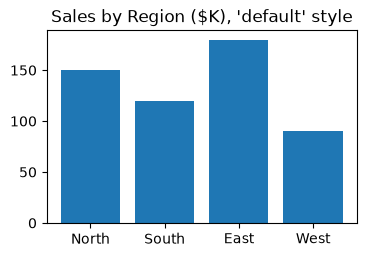

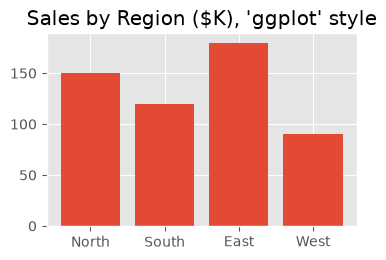

In [2]:
regions = ['North', 'South', 'East', 'West']
sales = [150, 120, 180, 90]                        ### quarterly sales in $K

for style in ['default', 'ggplot']:
    with plt.style.context(style):                 ### the style applies only inside this block
        fig, ax = plt.subplots(figsize=(4, 2.5))
        ax.bar(regions, sales)
        ax.set_title(f"Sales by Region ($K), '{style}' style")
        plt.show()

```{index} legend
```
### Legends for Axes



Legends are attached to an **axes** in the OO API. You typically supply `label=...` when plotting, then call `ax.legend()` to display the legend for that axes.


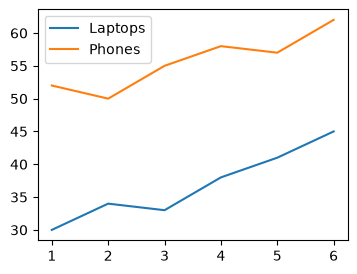

In [4]:
month = np.arange(1, 7)
laptops = np.array([30, 34, 33, 38, 41, 45])          ### units sold
phones = np.array([52, 50, 55, 58, 57, 62])

fig, ax = plt.subplots(figsize=(4, 3))

ax.plot(month, laptops, label="Laptops")   ### label= is what the legend shows
ax.plot(month, phones, label="Phones")
ax.legend()
plt.show()


If the legend overlaps the plotted data, pass a `loc=` argument to `ax.legend()` to move it.

Common values include string labels such as `'best'`, `'upper right'`, `'upper left'`, `'lower left'`, and `'lower right'`.


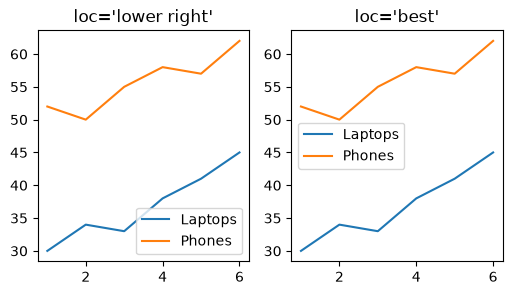

In [5]:
month = np.arange(1, 7)
laptops = np.array([30, 34, 33, 38, 41, 45])          ### units sold
phones = np.array([52, 50, 55, 58, 57, 62])

fig, ax = plt.subplots(1, 2, figsize=(6, 3))

ax[0].plot(month, laptops, label="Laptops")
ax[0].plot(month, phones, label="Phones")
ax[0].legend(loc='lower right')
ax[0].set_title("loc='lower right'")

ax[1].plot(month, laptops, label="Laptops")
ax[1].plot(month, phones, label="Phones")
ax[1].legend(loc='best')
ax[1].set_title("loc='best'")
plt.show()

In [6]:
### Exercise: Label Two Products
#   1. Create month = np.arange(1, 7),
#      tablets = np.array([18, 20, 19, 23, 22, 25]), and
#      watches = np.array([12, 15, 14, 16, 19, 21]).
#   2. Use fig, ax = plt.subplots(figsize=(4, 3)).
#   3. Plot month vs tablets with the label "Tablets" and
#      month vs watches with the label "Watches".
#   4. Show the legend in the upper left corner (loc='upper left').
#   5. Set the title to "Units Sold".
### Your code starts here.




### Your code ends here.

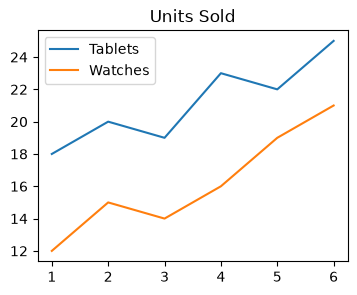

In [7]:
### Solution
import numpy as np
import matplotlib.pyplot as plt

month = np.arange(1, 7)
tablets = np.array([18, 20, 19, 23, 22, 25])
watches = np.array([12, 15, 14, 16, 19, 21])

fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(month, tablets, label='Tablets')
ax.plot(month, watches, label='Watches')
ax.legend(loc='upper left')
ax.set_title('Units Sold')
plt.show()

```{index} axis range (set_xlim and set_ylim)
```
### Plot Range `set_xlim(), set_ylim()`

You can set axis ranges directly with `ax.set_xlim(...)` and `ax.set_ylim(...)`. The three charts below plot the same daily sales:

- **Default range:** Matplotlib fits the axes to the data, so the y-axis starts near 38, not 0.
- **Start at zero:** with `set_ylim(0, 80)`, the promotion spike looks like the rise it really is: the peak of about \$75K is nearly 80% above a normal day of about \$42K.
- **Zoomed in:** `set_xlim(14, 22)` and `set_ylim(30, 80)` show only the promotion week.

Axis ranges change what the reader sees, not the data. A y-axis that does not start at zero can make small differences look large, which matters most for bar charts.

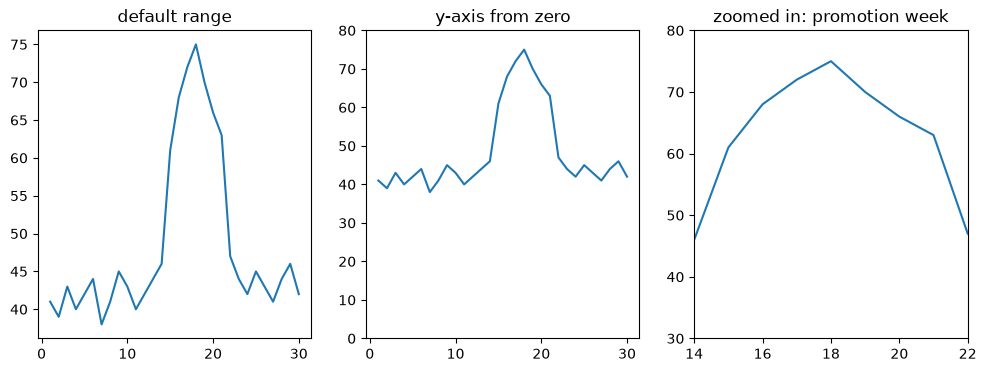

In [8]:
day = np.arange(1, 31)                  ### days in June
daily_sales = np.array([41, 39, 43, 40, 42, 44, 38, 41, 45, 43,
                        40, 42, 44, 46, 61, 68, 72, 75, 70, 66,
                        63, 47, 44, 42, 45, 43, 41, 44, 46, 42])   ### $K; promotion on days 15-21

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].plot(day, daily_sales)
axes[0].set_title("default range")

axes[1].plot(day, daily_sales)
axes[1].set_ylim(0, 80)          # y-axis starts at zero
axes[1].set_title("y-axis from zero")

axes[2].plot(day, daily_sales)
axes[2].set_ylim(30, 80)         # y-axis runs from 30 to 80
axes[2].set_xlim(14, 22)         # x-axis runs from day 14 to day 22
axes[2].set_title("zoomed in: promotion week")
plt.show()

In [9]:
### Exercise: Controlling Axis Ranges
#   1. Create month = np.arange(1, 13),
#      this_year = np.array([110, 104, 118, 121, 125, 119, 130, 128, 135, 150, 168, 190]), and
#      last_year = np.array([98, 95, 104, 108, 112, 110, 117, 115, 121, 133, 150, 171]).
#   2. Use fig, axes = plt.subplots(1, 2, figsize=(10, 4)).
#   3. On axes[0], plot month vs this_year and month vs last_year. Set title "Full Year".
#   4. On axes[1], plot the same data, then set:
#      - x-axis limits to [1, 6] using set_xlim
#      - y-axis limits to [80, 140] using set_ylim
#      Set title "First Half".
#   5. Call plt.tight_layout() at the end.
### Your code starts here.




### Your code ends here.

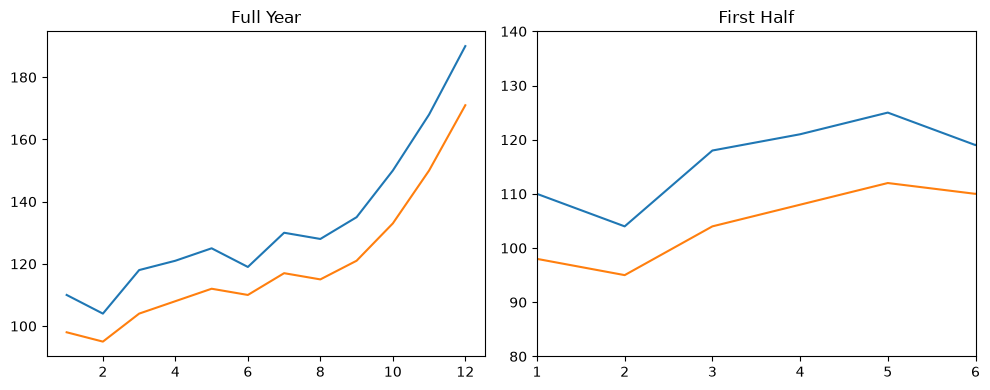

In [10]:
### Solution
import numpy as np
import matplotlib.pyplot as plt

month = np.arange(1, 13)
this_year = np.array([110, 104, 118, 121, 125, 119, 130, 128, 135, 150, 168, 190])
last_year = np.array([98, 95, 104, 108, 112, 110, 117, 115, 121, 133, 150, 171])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(month, this_year)
axes[0].plot(month, last_year)
axes[0].set_title('Full Year')
axes[1].plot(month, this_year)
axes[1].plot(month, last_year)
axes[1].set_xlim(1, 6)
axes[1].set_ylim(80, 140)
axes[1].set_title('First Half')
plt.tight_layout()
plt.show()

```{index} color, line style
```
### Colors, Line Width, and Style

Matplotlib gives you many options for customizing colors, line widths, and line styles.

```{index} format string
```
#### MATLAB-Style Format Strings


Matplotlib supports short MATLAB-style format strings such as `'b.-'`, which combine color, line style, and marker style in one compact argument.


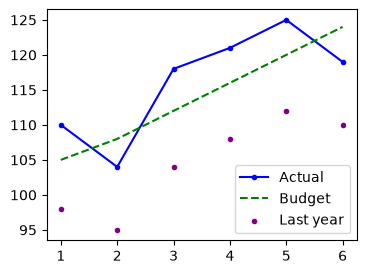

In [11]:
month = np.arange(1, 7)
actual = np.array([110, 104, 118, 121, 125, 119])      ### revenue in $K
budget = np.array([105, 108, 112, 116, 120, 124])
last_year = np.array([98, 95, 104, 108, 112, 110])

### MATLAB style line color and style
fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(month, actual, 'b.-', label='Actual')    # blue line with dots
ax.plot(month, budget, 'g--', label='Budget')    # green dashed line

### .plot() parameters can also be specified in a more explicit way
ax.scatter(month, last_year, color='purple', marker='.', label='Last year')   # explicit parameters instead of a format string
ax.legend()
plt.show()


```{index} color (hex code), alpha (transparency)
```
#### The `color=` Parameter


You can define colors by name (`'blue'`) or by hex code (`'#8B008B'`). When a chart has several lines, give each a `label=` and show a legend, so the reader knows which line is which. Avoid pairing red with green: they are hard to tell apart for many color-blind readers.

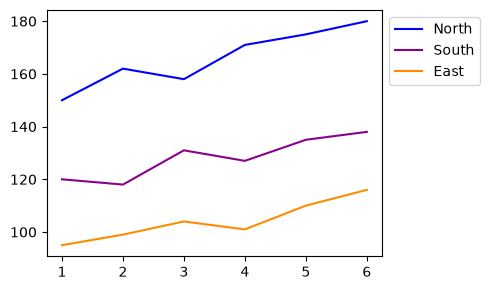

In [12]:
month = np.arange(1, 7)
north = np.array([150, 162, 158, 171, 175, 180])     ### revenue in $K
south = np.array([120, 118, 131, 127, 135, 138])
east = np.array([95, 99, 104, 101, 110, 116])

fig, ax = plt.subplots(figsize=(5, 3))

ax.plot(month, north, color="blue", label="North")        ### color by name
ax.plot(month, south, color="#8B008B", label="South")     ### RGB hex code
ax.plot(month, east, color="#FF8C00", label="East")       ### RGB hex code
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))   ### just outside the top-right corner, clear of the lines
plt.tight_layout()
plt.show()

`alpha` sets transparency from 0 (invisible) to 1 (opaque). It matters when marks overlap: below, 300 orders are plotted by number of items. At full opacity, overlapping points hide each other; with `alpha=0.2`, darker areas show where many orders pile up.

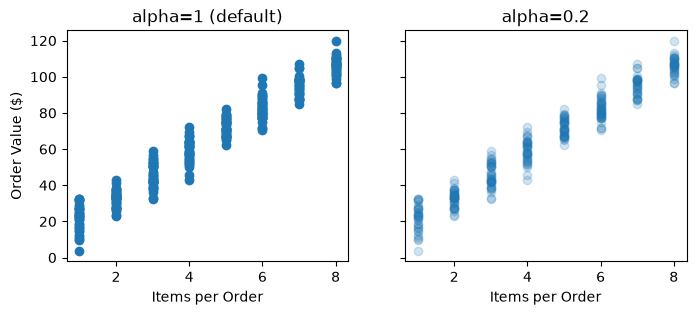

In [13]:
rng = np.random.default_rng(3)                        ### fixed seed: same numbers every run
items = rng.integers(1, 9, size=300)                  ### items per order
order_value = 10 + items * 12 + rng.normal(0, 6, size=300)   ### order value in $

fig, axes = plt.subplots(1, 2, figsize=(8, 3), sharey=True)
axes[0].scatter(items, order_value)
axes[0].set_title('alpha=1 (default)')
axes[1].scatter(items, order_value, alpha=0.2)
axes[1].set_title('alpha=0.2')
for ax in axes:
    ax.set_xlabel('Items per Order')
axes[0].set_ylabel('Order Value ($)')
plt.show()

```{index} marker, line width
```
#### Line and Marker Styles

To change line width, use `linewidth` or `lw`. To change line style, use `linestyle` or `ls`. Markers have a shape (`marker`), a size (`markersize` or `ms`), and colors for the fill and edge (`markerfacecolor`, `markeredgecolor`). Each line in the panels below is labeled with the setting that drew it.

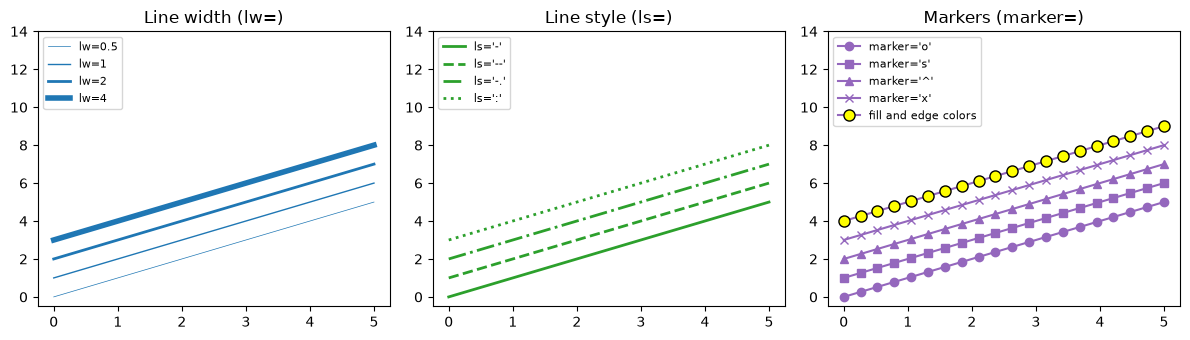

In [14]:
x = np.linspace(0, 5, 20)               ### simple numbers: this cell is a catalog of styles, not data

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

for i, lw in enumerate([0.5, 1, 2, 4]):                        ### line widths
    axes[0].plot(x, x + i, color='tab:blue', lw=lw, label=f'lw={lw}')
axes[0].set_title('Line width (lw=)')

for i, ls in enumerate(['-', '--', '-.', ':']):                ### line styles
    axes[1].plot(x, x + i, color='tab:green', lw=2, ls=ls, label=f"ls='{ls}'")
axes[1].set_title('Line style (ls=)')

for i, m in enumerate(['o', 's', '^', 'x']):                   ### marker shapes
    axes[2].plot(x, x + i, color='tab:purple', marker=m, label=f"marker='{m}'")
axes[2].plot(x, x + 4, color='tab:purple', marker='o', markersize=8,
             markerfacecolor='yellow', markeredgecolor='black', label='fill and edge colors')
axes[2].set_title('Markers (marker=)')

for ax in axes:
    ax.set_ylim(-0.5, 14)                   ### headroom so the legend sits above the lines
    ax.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

In [15]:
### Exercise: Style a Revenue Chart
#   1. Create month = np.arange(1, 7),
#      actual = np.array([110, 104, 118, 121, 125, 119]),
#      budget = np.array([105, 108, 112, 116, 120, 124]), and
#      last_year = np.array([98, 95, 104, 108, 112, 110]).
#   2. Use fig, ax = plt.subplots(figsize=(5, 3)).
#   3. Plot actual with the format string 'b.-' and the label "Actual".
#   4. Plot budget with color='gray', ls='--', lw=1, marker='s', and the label "Budget".
#   5. Plot last_year with color='#FF8C00', lw=3, alpha=0.5, and the label "Last year".
#   6. Set the title to "Actual, Budget, and Last Year" and show the legend.
### Your code starts here.




### Your code ends here.

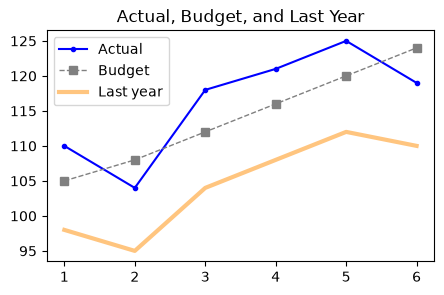

In [16]:
### Solution
import numpy as np
import matplotlib.pyplot as plt

month = np.arange(1, 7)
actual = np.array([110, 104, 118, 121, 125, 119])
budget = np.array([105, 108, 112, 116, 120, 124])
last_year = np.array([98, 95, 104, 108, 112, 110])

fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(month, actual, 'b.-', label='Actual')
ax.plot(month, budget, color='gray', ls='--', lw=1, marker='s', label='Budget')
ax.plot(month, last_year, color='#FF8C00', lw=3, alpha=0.5, label='Last year')
ax.set_title('Actual, Budget, and Last Year')
ax.legend()
plt.show()

```{index} plot types
```
## Common Plot Types

So far we have used line plots to introduce Matplotlib. Below are a few common plot types, shown in the OO style so the examples stay consistent with the rest of the notebook. Each example reuses the styling tools from the first half of this section (labels, legends, colors, transparency, and axis ranges), because a chart for a manager needs both the right type and clear styling.


```{index} scatter plot
```
### Scatter Plot

A **scatter plot** displays individual data points as dots on a two-dimensional plane, with one variable on the x-axis and another on the y-axis. Each dot represents a single observation. Scatter plots are useful for visualizing the relationship or correlation between two continuous variables, and for identifying patterns, clusters, or outliers in the data.


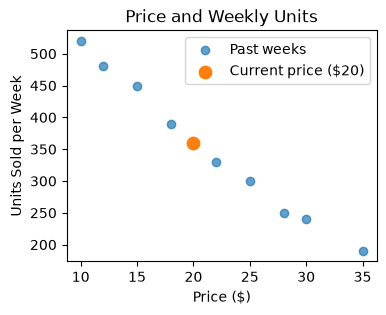

In [17]:
price = np.array([10, 12, 15, 18, 20, 22, 25, 28, 30, 35])     ### product price in $
units = np.array([520, 480, 450, 390, 360, 330, 300, 250, 240, 190])   ### units sold per week

fig, ax = plt.subplots(figsize=(4, 3))
ax.scatter(price, units, alpha=0.7, label='Past weeks')
ax.scatter(20, 360, color='tab:orange', s=80, label='Current price ($20)')   ### s= sets the marker size
ax.set_xlabel('Price ($)')
ax.set_ylabel('Units Sold per Week')
ax.set_title('Price and Weekly Units')
ax.legend()
plt.show()

The points slope downward: at higher prices, the store sells fewer units each week. A scatter plot shows that two measures move together; on its own it does not prove that price causes the drop. Coloring one point and naming it in the legend points the reader to the week that matters now.

In [18]:
### Exercise: Store Size and Revenue
#   1. Create store_size = np.array([8, 10, 12, 15, 18, 20, 22, 25, 28, 30])   (1,000 sq ft) and
#      revenue = np.array([95, 110, 118, 140, 155, 170, 168, 195, 210, 220])   ($K per month).
#   2. Use fig, ax = plt.subplots(figsize=(4, 3)).
#   3. Draw a scatter plot of store_size (x) vs revenue (y).
#   4. Label the axes "Store Size (1,000 sq ft)" and "Monthly Revenue ($K)",
#      and set the title to "Store Size and Revenue".
### Your code starts here.




### Your code ends here.

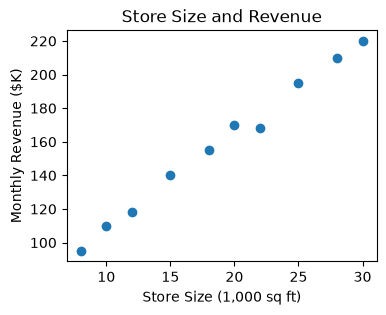

In [19]:
### Solution
import numpy as np
import matplotlib.pyplot as plt

store_size = np.array([8, 10, 12, 15, 18, 20, 22, 25, 28, 30])
revenue = np.array([95, 110, 118, 140, 155, 170, 168, 195, 210, 220])

fig, ax = plt.subplots(figsize=(4, 3))
ax.scatter(store_size, revenue)
ax.set_xlabel('Store Size (1,000 sq ft)')
ax.set_ylabel('Monthly Revenue ($K)')
ax.set_title('Store Size and Revenue')
plt.show()


```{index} bar plot
```
### Bar Plot

A **bar plot** displays categorical data as rectangular bars, where the height (or length) of each bar is proportional to the value it represents. The x-axis typically shows the categories and the y-axis shows the corresponding values. Bar plots are useful for comparing quantities across distinct groups or categories.


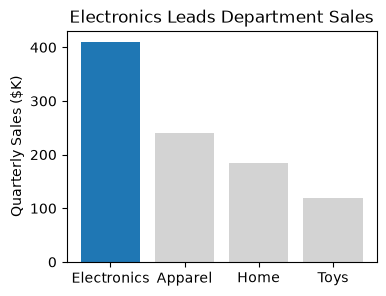

In [20]:
departments = ['Apparel', 'Electronics', 'Home', 'Toys']
sales = [240, 410, 185, 120]                   ### quarterly sales in $K

order = np.argsort(sales)[::-1]                ### positions from largest to smallest
sorted_departments = [departments[i] for i in order]
sorted_sales = [sales[i] for i in order]
colors = ['tab:blue'] + ['lightgray'] * (len(sorted_sales) - 1)   ### highlight only the leader

fig, ax = plt.subplots(figsize=(4, 3))
ax.bar(sorted_departments, sorted_sales, color=colors)
ax.set_ylabel('Quarterly Sales ($K)')
ax.set_title('Electronics Leads Department Sales')
plt.show()

Electronics sells far more than the other departments. Three styling choices make that easy to see: the bars are sorted from largest to smallest (useful whenever the category order has no meaning of its own), only the leader is colored, and the title states the takeaway instead of just naming the data.


```{index} histogram, bin
```
### Histogram

A **histogram** displays the distribution of a continuous variable by dividing the data into bins (intervals) and counting how many values fall into each bin. The x-axis represents the value ranges, and the y-axis represents the frequency (count) of observations in each bin. Histograms are useful for visualizing the shape of a distribution — whether it is symmetric, skewed, or has multiple peaks.


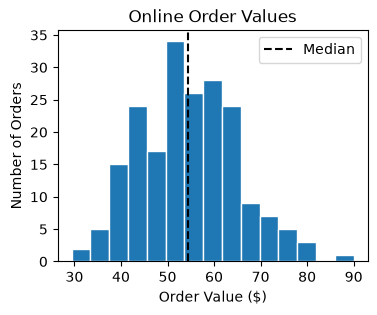

In [21]:
rng = np.random.default_rng(42)                        ### fixed seed: same numbers every run
order_values = rng.normal(loc=55, scale=12, size=200)  ### 200 online orders, in $

fig, ax = plt.subplots(figsize=(4, 3))
ax.hist(order_values, bins=15, edgecolor='white')      ### white edges separate the bins
ax.axvline(np.median(order_values), color='black', ls='--', label='Median')   ### vertical reference line
ax.set_xlabel('Order Value ($)')
ax.set_ylabel('Number of Orders')
ax.set_title('Online Order Values')
ax.legend()
plt.show()

The dashed line marks the median order, about \$55. Most orders fall between about \$40 and \$70, with fewer very small or very large orders. The number of **bins** changes what you see: too few bins hide the shape, and too many make it noisy. Try a few values:

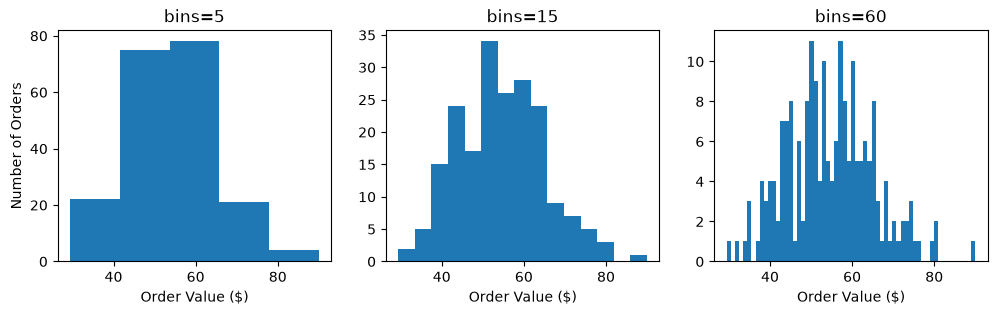

In [22]:
rng = np.random.default_rng(42)
order_values = rng.normal(loc=55, scale=12, size=200)

fig, axes = plt.subplots(1, 3, figsize=(12, 3), sharey=False)
for ax, bins in zip(axes, [5, 15, 60]):
    ax.hist(order_values, bins=bins)
    ax.set_title(f'bins={bins}')
    ax.set_xlabel('Order Value ($)')
axes[0].set_ylabel('Number of Orders')
plt.show()

In [23]:
### Exercise: Bar Chart and Histogram
#   The following data represent quarterly sales figures ($K) for four products
#   and daily website visits over 100 days.
#
#   products = ['Laptop', 'Phone', 'Tablet', 'Watch']
#   sales    = [320, 580, 140, 210]
#   visits   = np.random.default_rng(0).normal(loc=500, scale=80, size=100)
#
#   1. Create a figure with two side-by-side subplots: fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
#   2. On ax1, draw a bar chart of products vs. sales.
#      Set the title to "Quarterly Product Sales", x-label "Product", y-label "Sales ($K)".
#   3. On ax2, draw a histogram of visits using ax2.hist(visits, bins=15), 
#      color='orange', edgecolor='white', and alpha=0.7.
#      Set the title to "Daily Website Visits", x-label "Visits", y-label "Frequency".
#   4. Call plt.tight_layout() before displaying.
### Your code starts here.




### Your code ends here.

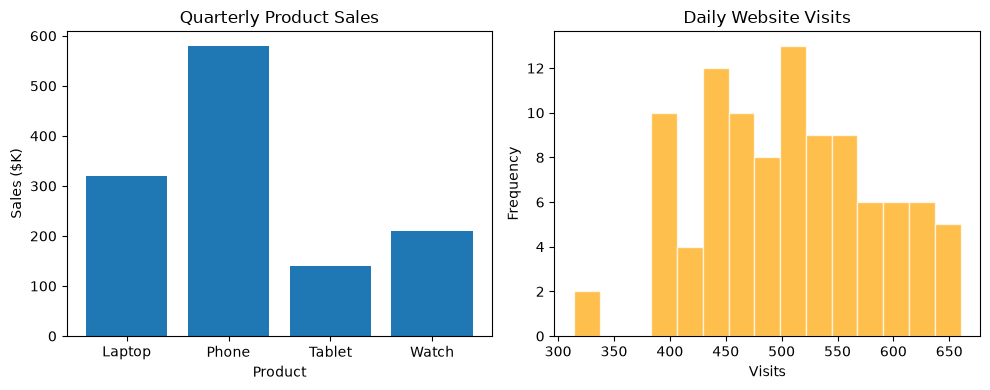

In [24]:
### Solution
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)
products = ['Laptop', 'Phone', 'Tablet', 'Watch']
sales = [320, 580, 140, 210]
visits = rng.normal(loc=500, scale=80, size=100)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.bar(products, sales)
ax1.set_title('Quarterly Product Sales')
ax1.set_xlabel('Product')
ax1.set_ylabel('Sales ($K)')
ax2.hist(visits, bins=15, color='orange', edgecolor='white', alpha=0.7)
ax2.set_title('Daily Website Visits')
ax2.set_xlabel('Visits')
ax2.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

```{index} boxplot, interquartile range, outlier
```
### Boxplot

A **boxplot** (also called a box-and-whisker plot) summarizes a distribution in one compact shape:

- **The box** spans from the first quartile (Q1) to the third quartile (Q3), so it holds the middle 50% of the values. Its height is the **interquartile range** (IQR).
- **The line** inside the box marks the **median**.
- **The whiskers** reach the most extreme values that lie within 1.5 × IQR of the box.
- **Points beyond the whiskers** are plotted individually as **outliers**.

When there are no outliers, the whiskers reach the minimum and maximum. Boxplots are useful for comparing distributions across groups.

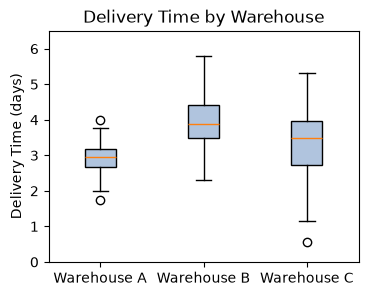

In [25]:
rng = np.random.default_rng(7)                         ### fixed seed: same numbers every run
### list comprehension to create delivery times (days) for three warehouses
delivery_days = [rng.normal(mean, sd, 100) for mean, sd in [(3.0, 0.5), (4.0, 0.8), (3.5, 0.9)]]

fig, ax = plt.subplots(figsize=(4, 3))
ax.boxplot(delivery_days, patch_artist=True,                   ### patch_artist=True lets the boxes be filled
           boxprops={'facecolor': 'lightsteelblue'})
ax.set_xticks([1, 2, 3], ['Warehouse A', 'Warehouse B', 'Warehouse C'])
ax.set_ylim(0, 6.5)                                            ### start at zero (see Plot Range)
ax.set_ylabel('Delivery Time (days)')
ax.set_title('Delivery Time by Warehouse')
plt.show()

Warehouse A is the fastest and most consistent. Warehouse B is the slowest, with a median near 4 days. Warehouse C sits in between on the median, but its tall box and long whiskers make it the least predictable, so a promised delivery date is hardest to keep there.

In [26]:
### Exercise: Compare Two Carriers
#   1. Create the delivery times (days) for two shipping carriers:
#      rng = np.random.default_rng(1)
#      carrier_a = rng.normal(2.5, 0.4, 80)
#      carrier_b = rng.normal(3.0, 0.9, 80)
#   2. Use fig, ax = plt.subplots(figsize=(4, 3)).
#   3. Draw a boxplot of [carrier_a, carrier_b].
#   4. Label the boxes with ax.set_xticks([1, 2], ['Carrier A', 'Carrier B']),
#      set the y-label "Delivery Time (days)", and the title "Delivery Time by Carrier".
### Your code starts here.




### Your code ends here.

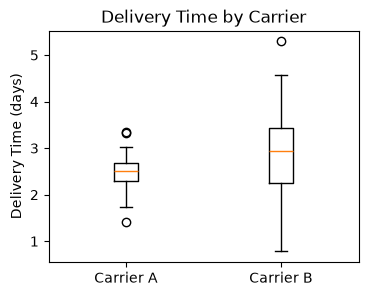

In [27]:
### Solution
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(1)
carrier_a = rng.normal(2.5, 0.4, 80)
carrier_b = rng.normal(3.0, 0.9, 80)

fig, ax = plt.subplots(figsize=(4, 3))
ax.boxplot([carrier_a, carrier_b])
ax.set_xticks([1, 2], ['Carrier A', 'Carrier B'])
ax.set_ylabel('Delivery Time (days)')
ax.set_title('Delivery Time by Carrier')
plt.show()

```{index} axes methods, plot parameters
```
## Quick Reference

The settings used most often in this chapter, in one place. Figure-level settings (`figsize`, `dpi`, `fig.suptitle()`, `fig.savefig()`, `sharey`) are covered in {doc}`0602-figures-axes`.

| Task | Code |
|---|---|
| Title and axis labels | `ax.set_title()`, `ax.set_xlabel()`, `ax.set_ylabel()` |
| Legend | `label=` on each series, then `ax.legend(loc=...)` |
| Axis range | `ax.set_xlim(min, max)`, `ax.set_ylim(min, max)` |
| Grid | `ax.grid(True)` |
| Line color | `color=` or `c=`: a name (`'red'`) or a hex code (`'#FF8C00'`) |
| Line width | `linewidth=` or `lw=` |
| Line style | `linestyle=` or `ls=`: `'-'`, `'--'`, `'-.'`, `':'` |
| Markers | `marker=` (`'o'`, `'s'`, `'^'`, `'x'`), `markersize=` or `ms=` |
| Transparency | `alpha=`, from 0 (invisible) to 1 (opaque) |
| Several at once | a format string such as `'r--'` (red, dashed) |
| Plot types | `ax.plot()`, `ax.bar()`, `ax.scatter()`, `ax.hist(bins=...)`, `ax.boxplot()` |
| Style for later charts | `plt.style.use()`, `plt.rcParams[...]` |

For every `ax.plot()` option, see [matplotlib.axes.Axes.plot](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.plot.html).

## Summary

- Figure-level methods (`fig.suptitle()`, `fig.tight_layout()`, `fig.savefig()`) act on the whole figure; axes methods (`ax.set_title()`, `ax.set_xlim()`, `ax.legend()`, `ax.grid()`) act on one chart.
- `rcParams` and style sheets (`plt.style.use()`) change the defaults for every chart drawn afterward.
- Give each series a `label=` and call `ax.legend()`; use `loc=` to move the legend off the data.
- `ax.set_xlim()` and `ax.set_ylim()` zoom in on part of the data or start an axis at zero.
- Colors (names or hex codes), `alpha`, line style, line width, and markers make series easy to tell apart. A format string such as `'r--'` sets several of these at once.
- Match the plot type to the question: a line plot for a trend, a bar plot for comparing categories, a scatter plot for a relationship, and a histogram or boxplot for a distribution.

A practical way to choose among the main Matplotlib workflows is:

- Use `plt.plot()` for quick, one-off exploration.
- Use `plt.subplots()` for most plotting tasks.
- Use `fig.add_axes()` when you need manual placement or inset axes.

## Further Reading

- [Customizing Matplotlib with style sheets and rcParams](https://matplotlib.org/stable/users/explain/customizing.html): every default you can change, and how to make your own style.
- [Plot types](https://matplotlib.org/stable/plot_types/index.html): a one-page overview of the chart types Matplotlib can draw.
- [Examples gallery](https://matplotlib.org/stable/gallery/index.html): hundreds of charts with the code that made them.